# **Capítulo 1: Fundamentos de Señales Análogas y Señales Continuas**

```
 Libro:  Analisis de Señales Utilizando Python
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 1** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


# **Ejemplo 1. Señal senoidal**

**A. SEÑAL SENOIDAL VISUALIZADA COMO CONTINUA**

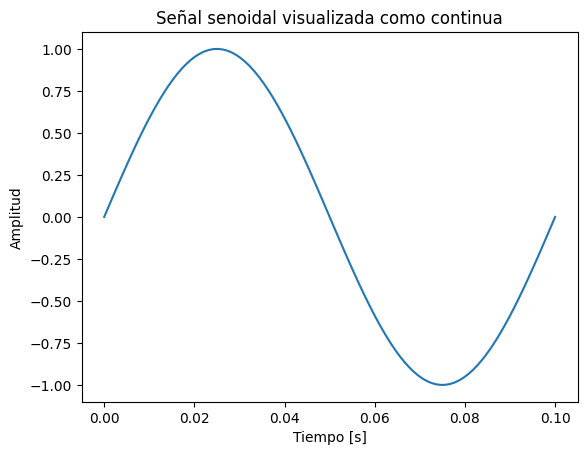

In [1]:
import numpy as np
import matplotlib.pyplot as plt

f = 10 # frecuencia [Hz]
fs = 1000 # frecuencia de muestreo [Hz]
t = np.linspace(0, 0.1, int(0.1*fs))

x = np.sin(2*np.pi*f*t)

plt.plot(t, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal senoidal visualizada como continua")
plt.show()

**B. SEÑAL VISUALIZADA COMO DISCRETA**

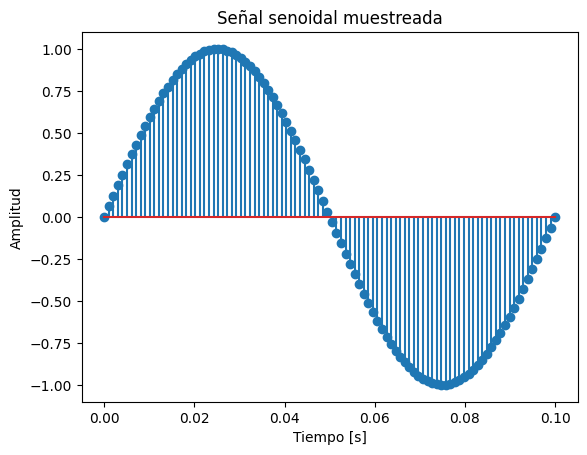

In [2]:
plt.stem(t, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal senoidal muestreada")
plt.show()

# **Ejemplo 2. Señales discretas con índice entero**

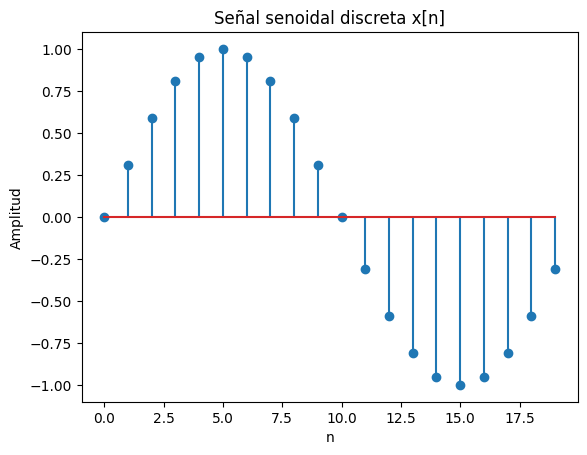

In [3]:
m = 20 # número de muestras
nc = 1 # número de ciclos
n = np.arange(m)

x = np.sin(2*np.pi*nc*n/m)

plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal senoidal discreta x[n]")
plt.show()

# **Ejemplo 3. Desplazamiento en tiempo continuo**

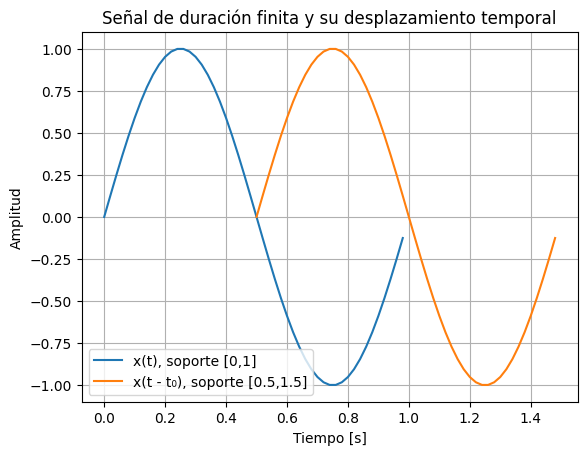

In [4]:
import numpy as np
import matplotlib.pyplot as plt

f = 1      # frecuencia [Hz]
fs = 50    # frecuencia de muestreo [Hz]
ti = 0
tf = 1
t0 = 0.5   # desplazamiento temporal [s] (retardo)

# Tiempo de la señal original (duración finita)
t = np.linspace(ti, tf, int((tf - ti)*fs), endpoint=False)
x = np.sin(2*np.pi*f*t)

# Tiempo de la señal desplazada (misma forma, pero empieza después)
t_shift = t + t0
x_shift = np.sin(2*np.pi*f*(t_shift - t0))  # equivalente a sin(2π f t)

plt.plot(t, x, label="x(t), soporte [0,1]")
plt.plot(t_shift, x_shift, label="x(t - t₀), soporte [0.5,1.5]")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal de duración finita y su desplazamiento temporal")
plt.legend()
plt.grid(True)
plt.show()



# **Ejemplo 4. Desplazamiento en tiempo discreto**

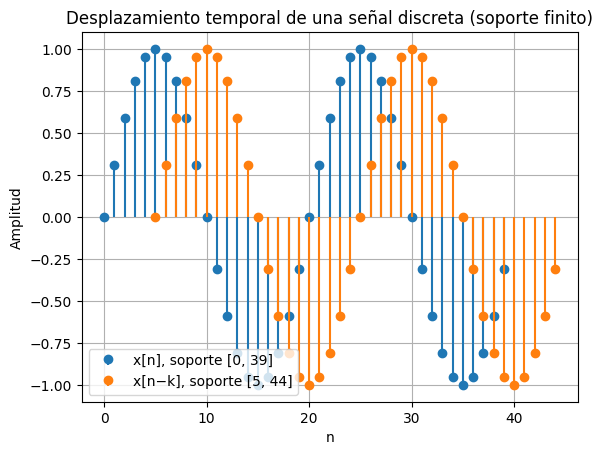

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la señal
m = 40
nc = 2
k = 5

# Eje temporal discreto
n = np.arange(m)

# Señal original
x = np.sin(2 * np.pi * nc * n / m)

# Señal desplazada: x[n-k]
n_shift = n + k
x_shift = x

# Gráficas (cada plt.stem en una sola línea)
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=" ", label='x[n], soporte [0, 39]')
plt.stem(n_shift, x_shift, linefmt='C1-', markerfmt='C1o', basefmt=" ", label='x[n−k], soporte [5, 44]')

# Formato
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Desplazamiento temporal de una señal discreta (soporte finito)")
plt.legend()
plt.grid(True)
plt.show()


# **Ejemplo 5. Inversión temporal de señales de soporte finito en tiempo continuo**

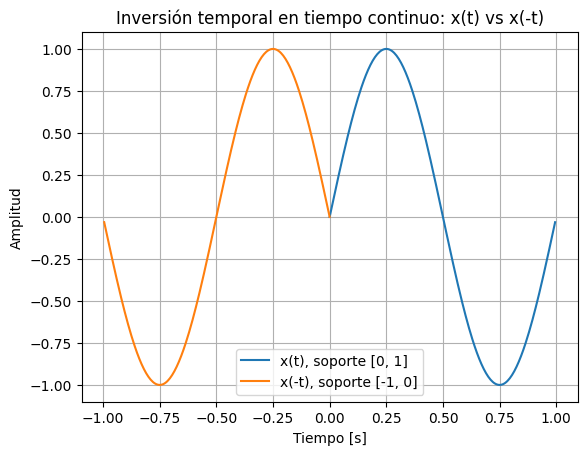

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
f = 1       # frecuencia de la señal [Hz]
fs = 200    # frecuencia de muestreo para visualización [Hz]
ti = 0
tf = 1

# Señal original (soporte finito en [ti, tf))
t = np.linspace(ti, tf, int((tf - ti) * fs), endpoint=False)
x = np.sin(2 * np.pi * f * t)

# Señal invertida temporalmente
# La inversión x(-t) se implementa invirtiendo el eje temporal
# y reordenando las muestras para mantener un eje creciente
t_inv = -t[::-1]     # eje temporal invertido
x_inv = x[::-1]      # muestras invertidas

# Gráficas
plt.plot(t, x, label="x(t), soporte [0, 1]")
plt.plot(t_inv, x_inv, label="x(-t), soporte [-1, 0]")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Inversión temporal en tiempo continuo: x(t) vs x(-t)")
plt.legend()
plt.grid(True)
plt.show()


# **Ejemplo 6. Inversión temporal de señales de soporte finito en tiempo continuo y discreto**

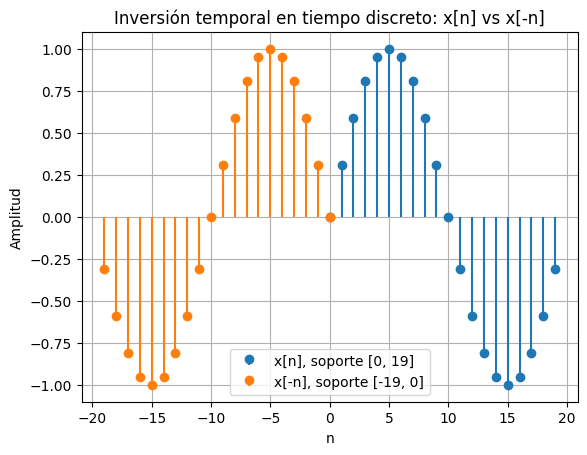

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
m = 20      # número de muestras
nc = 1      # número de ciclos en la ventana de m muestras

# Señal original (tiempo discreto) con soporte finito en [0, m-1]
n = np.arange(m)
x = np.sin(2 * np.pi * nc * n / m)

# Inversión temporal: x[-n]
# Para graficar de izquierda a derecha, invertimos el eje y reordenamos las muestras
n_inv = -n[::-1]   # soporte [- (m-1), 0]
x_inv = x[::-1]    # mismas muestras, en orden inverso

# Gráfica
plt.stem(n, x, linefmt='C0-', markerfmt='C0o', basefmt=" ",
         label=f"x[n], soporte [0, {m-1}]")
plt.stem(n_inv, x_inv, linefmt='C1-', markerfmt='C1o', basefmt=" ",
         label=f"x[-n], soporte [-{m-1}, 0]")

plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Inversión temporal en tiempo discreto: x[n] vs x[-n]")
plt.legend()
plt.grid(True)
plt.show()




# **Ejemplo 7. Compresión de una señal en tiempo continuo**

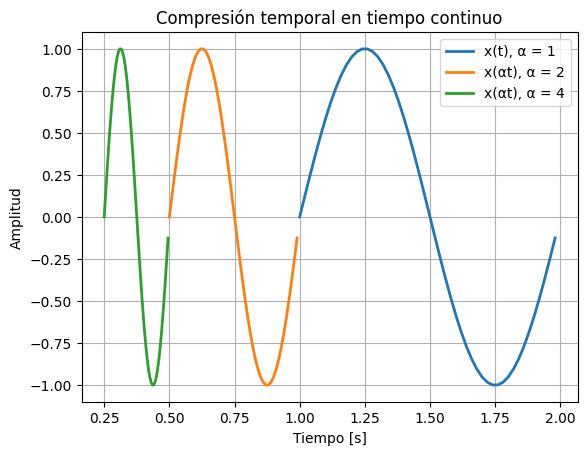

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
f = 1      # frecuencia de la señal [Hz]
fs = 50    # frecuencia de muestreo para visualización [Hz]
ti = 1     # tiempo inicial [s]
tf = 2     # tiempo final [s]

# Vector temporal original (α = 1)
t = np.linspace(ti, tf - 1/fs, int((tf - ti) * fs))
x = np.sin(2 * np.pi * f * t)

# Compresión temporal
alpha2 = 2
alpha4 = 4

# Nuevos ejes temporales creados a partir de t
t2 = t / alpha2
t4 = t / alpha4

# Señales comprimidas
x2 = np.sin(2 * np.pi * f * (alpha2 * t2))
x4 = np.sin(2 * np.pi * f * (alpha4 * t4))

# Gráfica
plt.plot(t,  x,  label='x(t), α = 1', linewidth=2)
plt.plot(t2, x2, label='x(αt), α = 2', linewidth=2)
plt.plot(t4, x4, label='x(αt), α = 4', linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Compresión temporal en tiempo continuo")
plt.legend()
plt.grid(True)
plt.show()



# **Ejemplo 8. Dilatación de una señal en tiempo continuo**

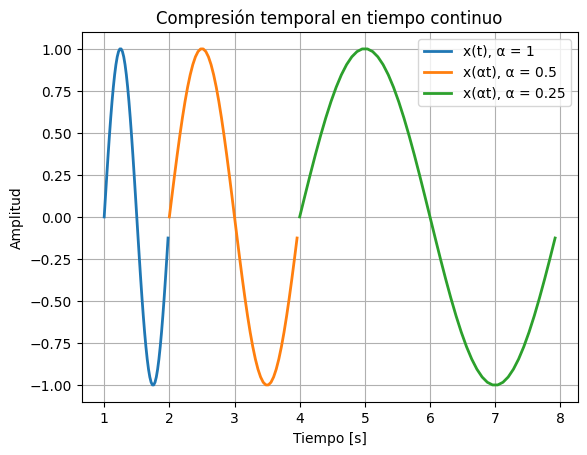

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
f = 1      # frecuencia de la señal [Hz]
fs = 50    # frecuencia de muestreo para visualización [Hz]
ti = 1     # tiempo inicial [s]
tf = 2     # tiempo final [s]

# Vector temporal original (α = 1)
t = np.linspace(ti, tf - 1/fs, int((tf - ti) * fs))
x = np.sin(2 * np.pi * f * t)

# Dilatación temporal
alpha2 = 0.5
alpha4 = 0.25

# Nuevos ejes temporales creados a partir de t
t2 = t / alpha2
t4 = t / alpha4

# Señales dilatadas
x2 = np.sin(2 * np.pi * f * (alpha2 * t2))
x4 = np.sin(2 * np.pi * f * (alpha4 * t4))

# Gráfica
plt.plot(t,  x,  label='x(t), α = 1', linewidth=2)
plt.plot(t2, x2, label='x(αt), α = 0.5', linewidth=2)
plt.plot(t4, x4, label='x(αt), α = 0.25', linewidth=2)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Compresión temporal en tiempo continuo")
plt.legend()
plt.grid(True)
plt.show()

# **Ejemplo 9. Compresión señal discreta**

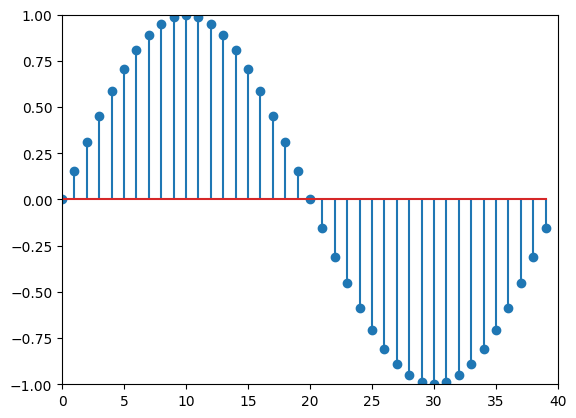

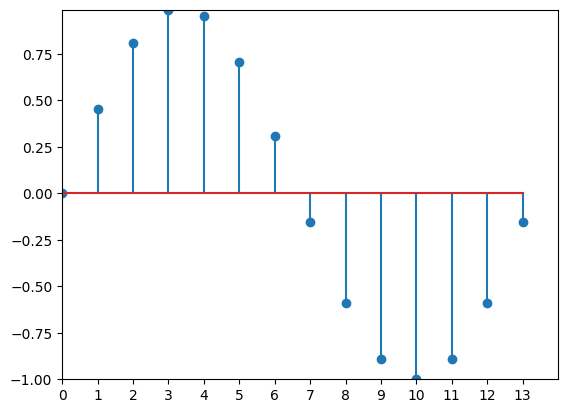

In [10]:
import numpy as np
import matplotlib.pyplot as plt

m = 40
nc = 1
α = 3  # prueba con 2, 3, 4...

n = np.arange(m)  # entero
x = np.sin(2 * np.pi * nc * n / m)

x_new = x[::α]
n_new = np.arange(len(x_new))  # 0..len(x_new)-1

plt.stem(n, x)
plt.axis([n.min(), n.max()+1, x.min(), x.max()])
plt.show()

plt.stem(n_new, x_new)
plt.axis([n_new.min(), n_new.max()+1, x_new.min(), x_new.max()])
plt.xticks(n_new)  # ticks enteros
plt.show()


# **Ejemplo 10. Dilatación señal discreta, caso α=1/q**

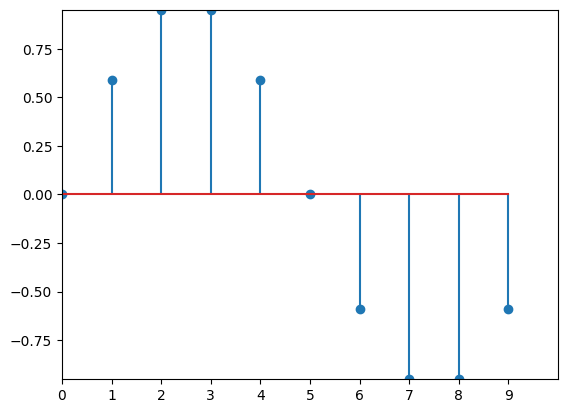

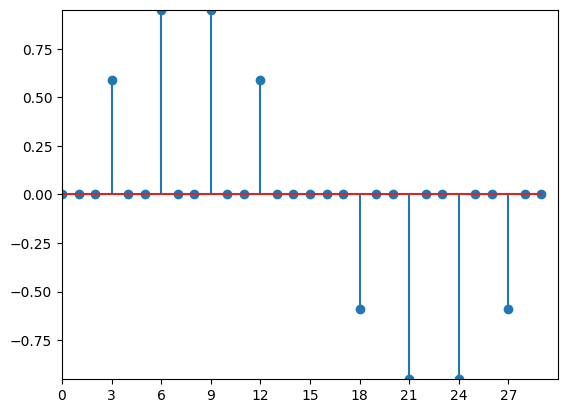

In [11]:
import numpy as np
import matplotlib.pyplot as plt

m = 10      # número de muestras
nc = 1      # número de ciclos

q = 3       #  q es entero
α = 1/ q

# Señal original (tiempo discreto entero)
n = np.arange(m)
x = np.sin(2 * np.pi * nc * n / m)

# Dilatación
L = int(round(1 / α))      # factor entero
n_new = np.arange(m * L)   # eje discreto entero
x_new = np.zeros(m * L)
x_new[::L] = x             # insertar ceros

# Señal original
plt.stem(n, x)
plt.axis([n.min(), n.max()+1, x.min(), x.max()])
plt.xticks(n)
plt.show()

# Señal dilatada
plt.stem(n_new, x_new)
plt.axis([n_new.min(), n_new.max()+1, x_new.min(), x_new.max()])
plt.xticks(n_new[::L])     # 👈 ticks cada L
plt.show()


# **Ejemplo 11. Dilatación señal discreta, caso α=p/q**

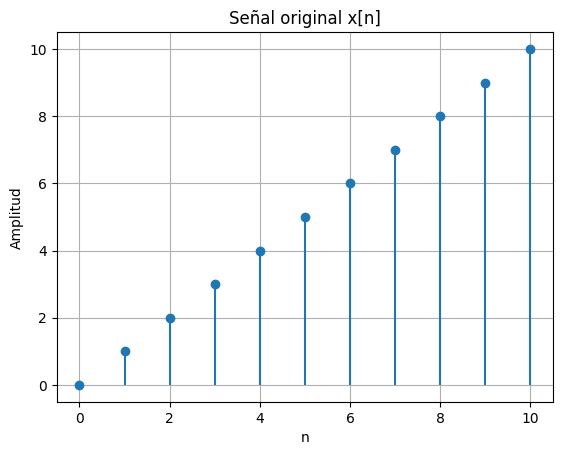

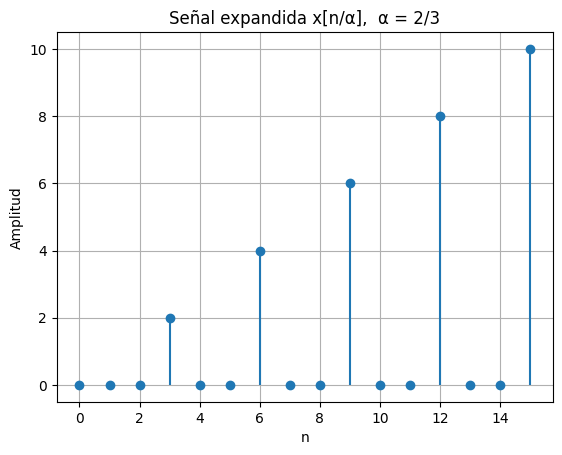

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Señal original
n = np.arange(0, 11)      # 0..10
x = np.arange(len(n))    # ejemplo: x[n] = n

# Factor de expansión
alpha = 2/3
ratio = 1/alpha          # 3/2

# Mapeo de índices
n_targets = ratio * n
n_int_mask = np.isclose(n_targets, np.round(n_targets))
n_targets_int = np.round(n_targets[n_int_mask]).astype(int)

# Nueva señal expandida
N_new = n_targets_int.max() + 1
x_new = np.zeros(N_new)
x_new[n_targets_int] = x[n_int_mask]

# Gráfica señal original
plt.figure()
plt.stem(n, x, basefmt=" ")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal original x[n]")
plt.grid(True)
plt.show()

# Gráfica señal expandida
plt.figure()
plt.stem(np.arange(N_new), x_new, basefmt=" ")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal expandida x[n/α],  α = 2/3")
plt.grid(True)
plt.show()



# **Ejemplo 12. Combinación de transformaciones en señal discreta**

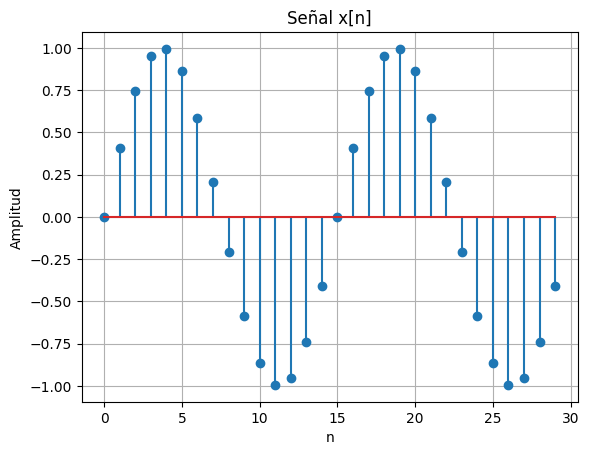

In [13]:
import numpy as np
import matplotlib.pyplot as plt

m = 30      # número de muestras de la señal
nc = 2      # número de ciclos de la señal
n = np.arange(0, m)              # eje temporal discreto
x = np.sin(2 * np.pi * nc * n/m) # señal discreta

plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal x[n]")
plt.grid(True)


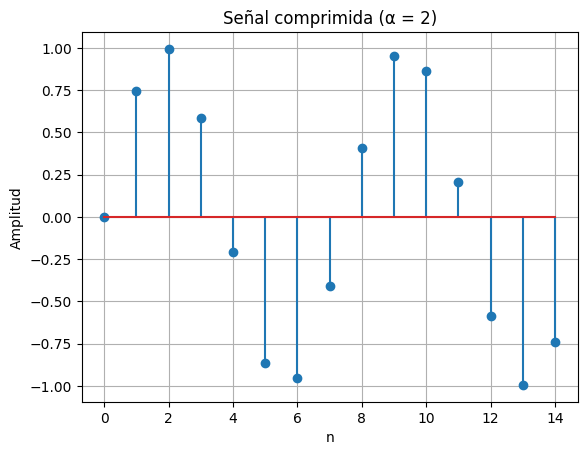

In [14]:
# Compresión de la señal
alpha = 2

n_new = np.arange(0, int(np.ceil(m/alpha)))
x_new = x[::alpha]

plt.stem(n_new, x_new)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal comprimida (α = 2)")
plt.grid(True)


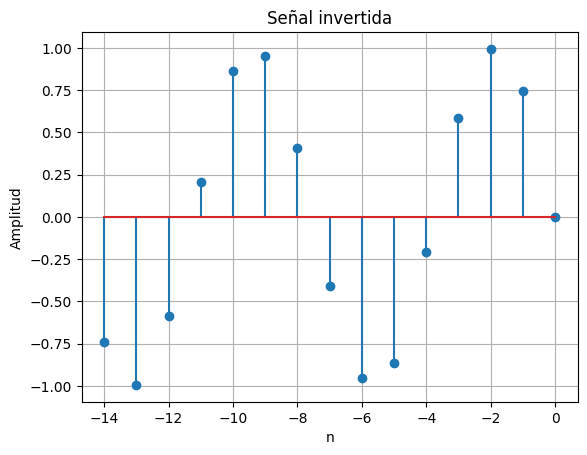

In [15]:
# Inversión de la señal
n_inv = -n_new

plt.stem(n_inv, x_new)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal invertida")
plt.grid(True)


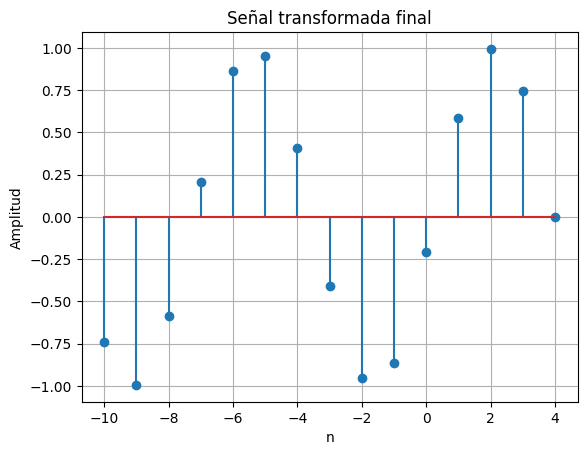

In [16]:
# Desplazamiento temporal
k = 4
n_disp = n_inv + k

plt.stem(n_disp, x_new)
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Señal transformada final")
plt.grid(True)
plt.show()


# **Ejemplo 17. Sistema invariante**

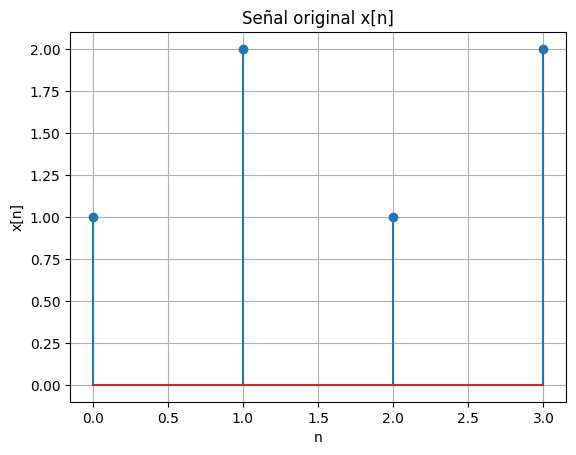

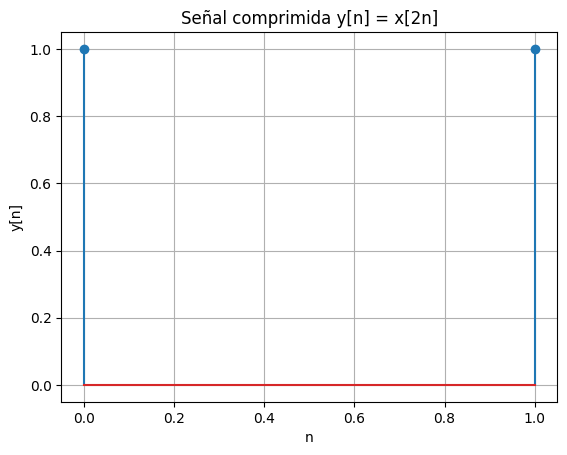

In [17]:
import numpy as np
import matplotlib.pyplot as plt

m = 4
n = np.linspace(0, m-1, m)
x = np.array([1, 2, 1, 2])

α = 2
n_new = np.linspace(0, int((m-1)/α), int(m/α))
x_new = x[::α]


# Señal original
plt.figure()
plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Señal original x[n]")
plt.grid(True)

# Señal comprimida
plt.figure()
plt.stem(n_new, x_new)
plt.xlabel("n")
plt.ylabel("y[n]")
plt.title("Señal comprimida y[n] = x[2n]")
plt.grid(True)

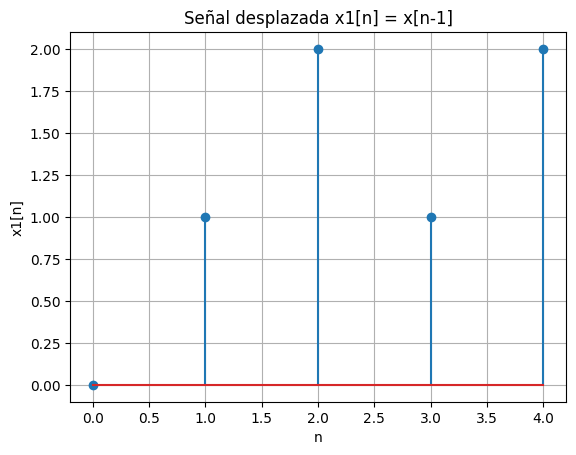

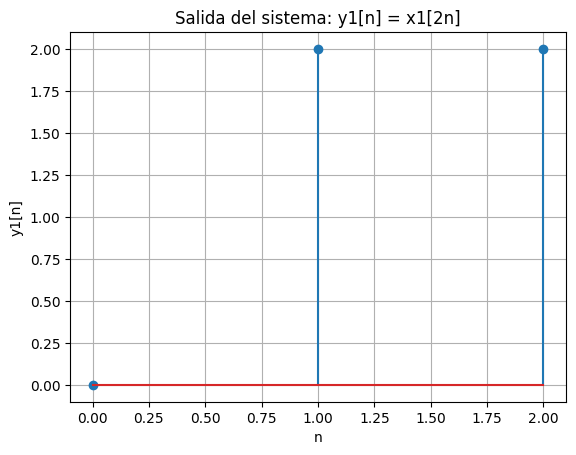

In [18]:

# Señal desplazada x1[n] = x[n-1]
m = 4
n = np.arange(0, m+1)
x1 = np.array([0, 1, 2, 1, 2])

# Sistema: y[n] = x[2n]
α = 2
n_new = np.arange(0, int(m/α) + 1)
y1 = x1[::α]

# Señal desplazada
plt.figure()
plt.stem(n, x1)
plt.xlabel("n")
plt.ylabel("x1[n]")
plt.title("Señal desplazada x1[n] = x[n-1]")
plt.grid(True)

# Salida del sistema para la señal desplazada
plt.figure()
plt.stem(n_new, y1)
plt.xlabel("n")
plt.ylabel("y1[n]")
plt.title("Salida del sistema: y1[n] = x1[2n]")
plt.grid(True)


Libro: Analisis de Señales Utilizando Python

---


Versión: 2026 – Material complementario para Google Colab.